<a href="https://colab.research.google.com/github/carlos-000-carlos/Challenge_3-TelecomX_parte2_BR-Cabral/blob/main/TelecomX2_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

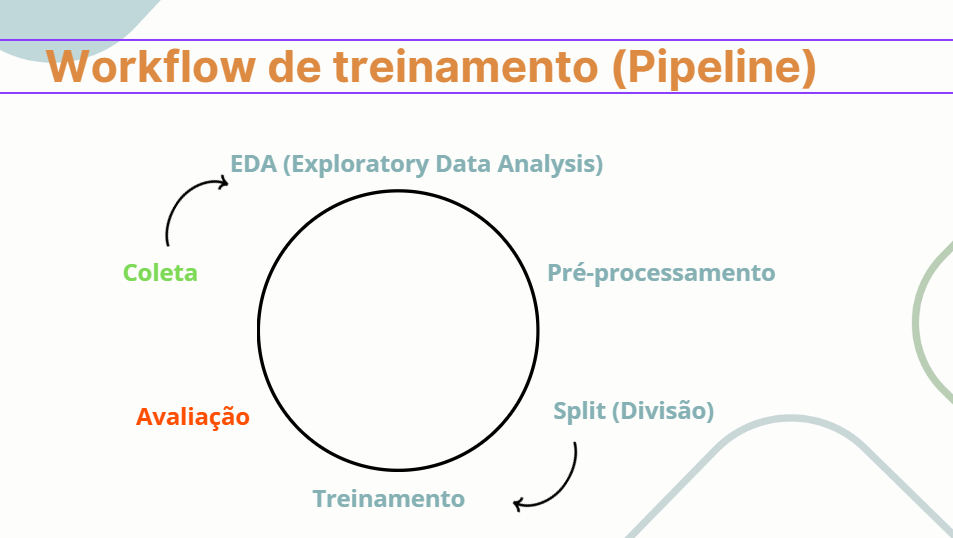

## Etapa 1 - 📌 Extração (Coleta dos Dados):

In [210]:
# import das bibliotecas mais comuns a serem usadas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [211]:
# Extração dos dados através do link do arquivo de dados que já está no GitHub
dados = pd.read_csv('https://raw.githubusercontent.com/carlos-000-carlos/Challenge_3-TelecomX_parte2_BR-Cabral/refs/heads/main/dados_tratados.csv')
dados.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [212]:
# Explorando as colunas que temos no nosso DataFrame
dados.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [213]:
# Explorando as colunas e visualizando seus tipos de dados
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


## Etapa 2 - 🛠️ Pré-Processamento:


Passo 1 - ❌ Remoção das Colunas Irrelevantes

In [214]:
# Removendo a coluna "CustomerID"
dados = dados.drop(columns = ['CustomerID'])

In [215]:
# Criamos uma lista com os nomes das colunas do Dataframe
colunas = list(dados.columns)
colunas


['Churn',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'Tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'ChargesDaily',
 'ChargesMonthly',
 'ChargesTotal']

In [216]:
# Aplicando o método "unique" a várias colunas de uma só vez
valores_unicos = dados[colunas].apply(pd.Series.unique)
print(valores_unicos)

Churn                                                       [No, Yes]
Gender                                                 [Female, Male]
SeniorCitizen                                               [No, Yes]
Partner                                                     [Yes, No]
Dependents                                                  [Yes, No]
Tenure              [9, 4, 13, 3, 71, 63, 7, 65, 54, 72, 5, 56, 34...
PhoneService                                                [Yes, No]
MultipleLines                                               [No, Yes]
InternetService                                [DSL, Fiber optic, No]
OnlineSecurity                                              [No, Yes]
OnlineBackup                                                [Yes, No]
DeviceProtection                                            [No, Yes]
TechSupport                                                 [Yes, No]
StreamingTV                                                 [Yes, No]
StreamingMovies     

In [217]:
dados.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


Passo 2 - 🖇 Agrupamento de "No" com "No internet service"

In [218]:
# Colunas escolhidas para agrupar
colunas_para_agrupar = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for nome in colunas_para_agrupar:
  dados[nome] = dados[nome].replace('No internet service', 'No')

In [219]:
dados.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


Passo 3 - ❓Ø❓ Verificação de Valores Nulos

In [220]:
# Usamos a função "isnull"
dados.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Etapa 3 - 📊 EDA (Análise Exploratória dos Dados)

Passo 1 - 🔀 Correlação entre Variáveis Numéricas

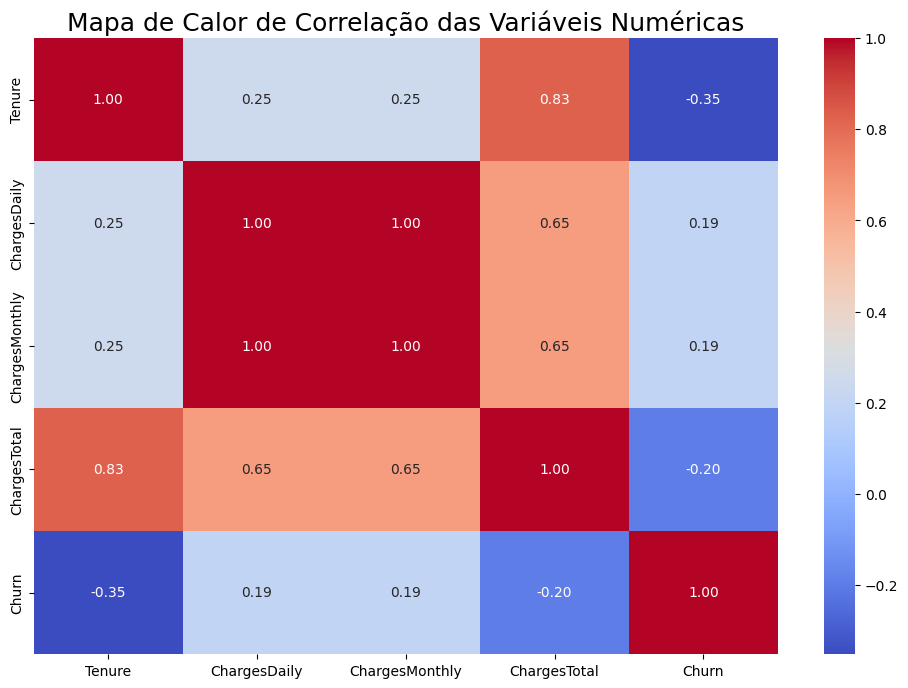

In [221]:
# Selecionamos somente variáveis numéricas
df_variaveis_numericas = dados.select_dtypes(include = ['int64', 'float64'])

# Convertemos a variável "Churn" para valores numéricos
df_variaveis_numericas['Churn'] = dados['Churn'].map({'Yes' : 1, 'No' : 0})

# Aplicamos a matriz de correlação
corr_matrix = df_variaveis_numericas.corr()

# Plotagem da visualização
plt.figure(figsize = (12, 8))
sns.heatmap(corr_matrix, annot = True,
            cmap = 'coolwarm', fmt = ".2f")
plt.title("Mapa de Calor de Correlação das Variáveis Numéricas",
          fontsize = 18)
plt.show()

In [222]:
# Retirando as colunas "ChargesDaily" e "ChargesTotal", pois não devem entrar na correlação
dados = dados.drop(columns = ['ChargesDaily', 'ChargesTotal'])

In [223]:
dados.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9


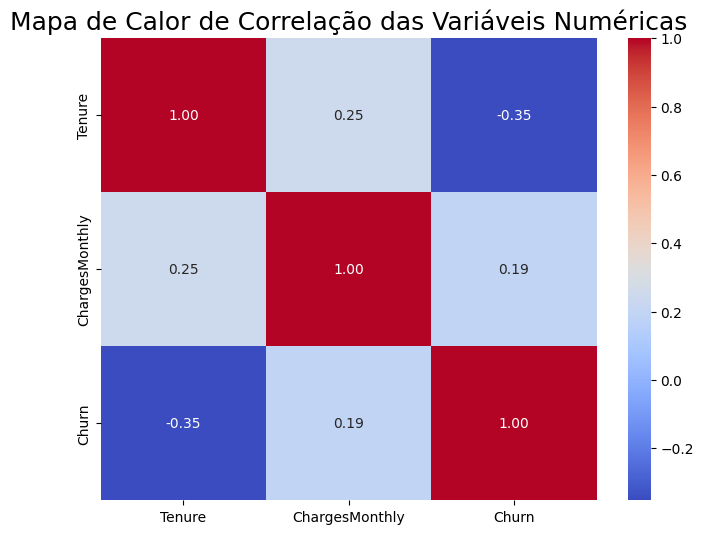

In [225]:
# Selecionamos somente variáveis numéricas
df_variaveis_numericas = dados.select_dtypes(include = ['int64', 'float64'])

# Convertemos a variável "Churn" para valores numéricos
df_variaveis_numericas['Churn'] = dados['Churn'].map({'Yes' : 1, 'No' : 0})

# Aplicamos a matriz de correlação
corr_matrix = df_variaveis_numericas.corr()

# Plotagem da visualização
plt.figure(figsize = (8, 6))
sns.heatmap(corr_matrix, annot = True,
            cmap = 'coolwarm', fmt = ".2f")
plt.title("Mapa de Calor de Correlação das Variáveis Numéricas",
          fontsize = 18)
plt.show()

Passo 2 - 📊📈 Análise de Evasão por Categoria (Variáveis Categóricas)

 ⣏⣹ 👁️‍🗨️ Seleção de Variáveis Categóricas

In [177]:
# Selecionando apenas colunas categóricas
colunas_categoricas = dados.select_dtypes(include = ['object']).columns
colunas_categoricas = colunas_categoricas.drop('Churn')

𝄜 % Tabela de Proporção de Evasão X Categorias

In [178]:
# Laço de repetição para criar as tabelas de evasão dentro de cada categoria
for column in colunas_categoricas:
  print(f'\n\n 🔢 ❯❯❯❯ Análise da Evasão X {column}')
  display(round(pd.crosstab(dados[column], dados['Churn'],
                      normalize = 'index') * 100, 2))



 🔢 ❯❯❯❯ Análise da Evasão X Gender


Churn,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16




 🔢 ❯❯❯❯ Análise da Evasão X SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.39,23.61
Yes,58.32,41.68




 🔢 ❯❯❯❯ Análise da Evasão X Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83




 🔢 ❯❯❯❯ Análise da Evasão X PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57




 🔢 ❯❯❯❯ Análise da Evasão X PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


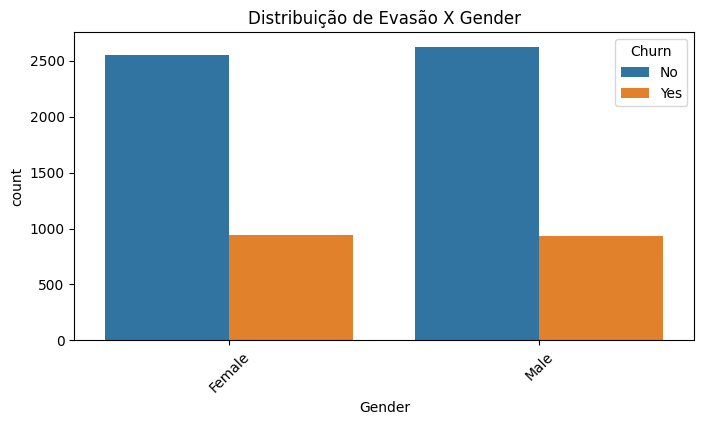

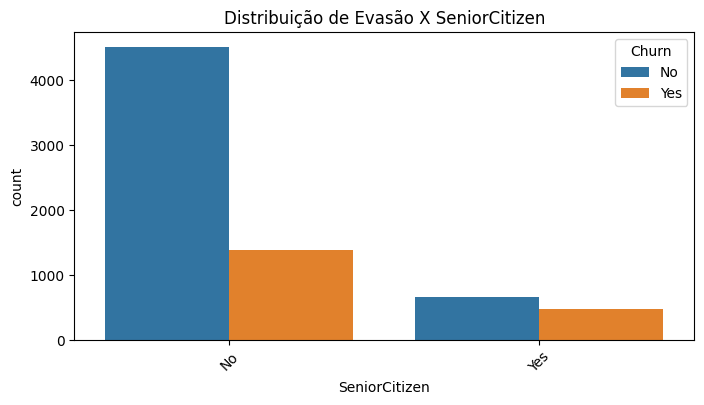

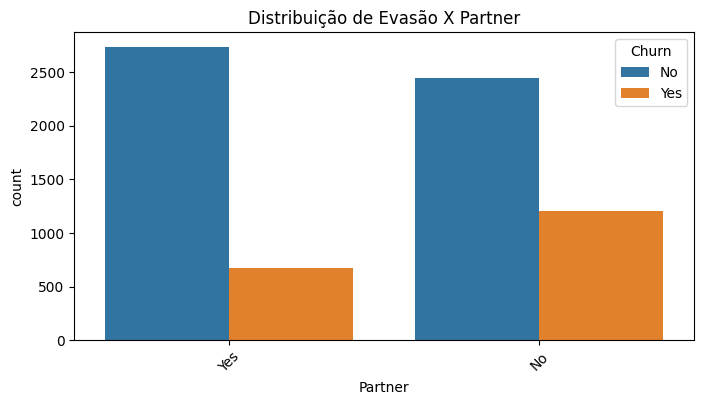

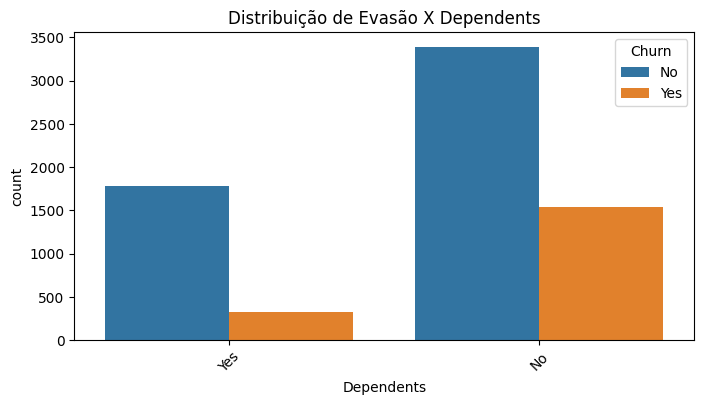

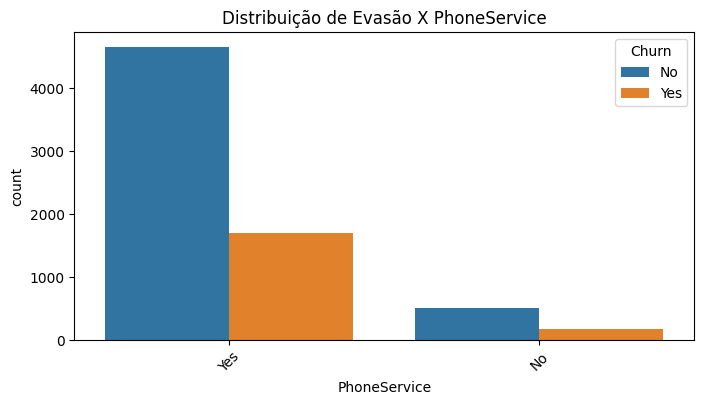

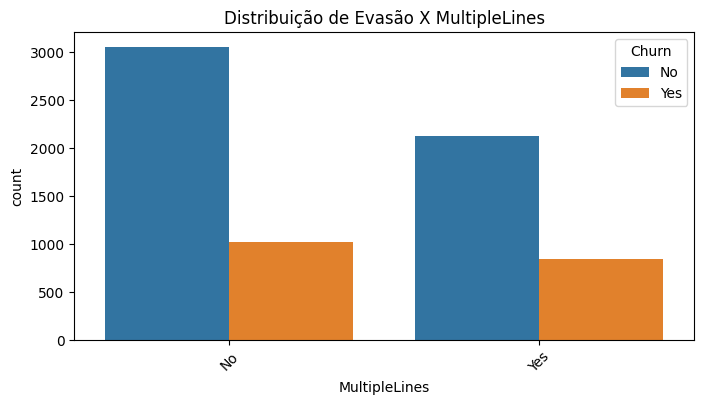

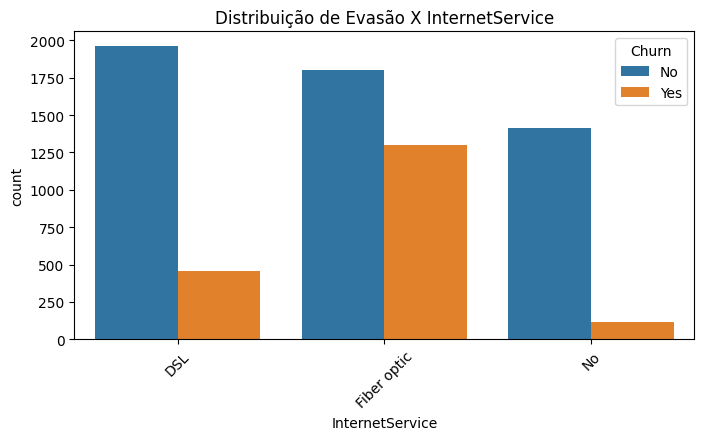

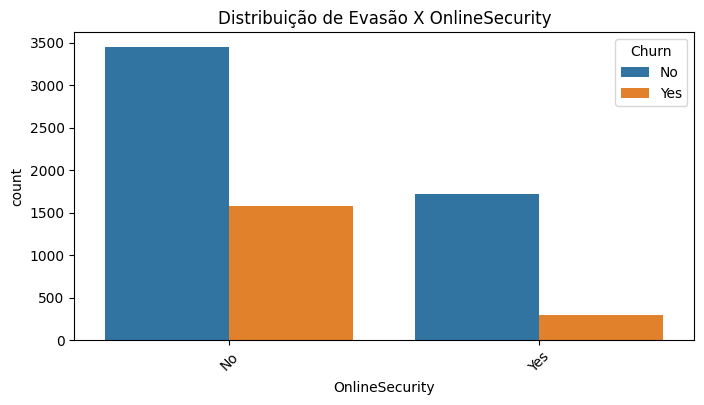

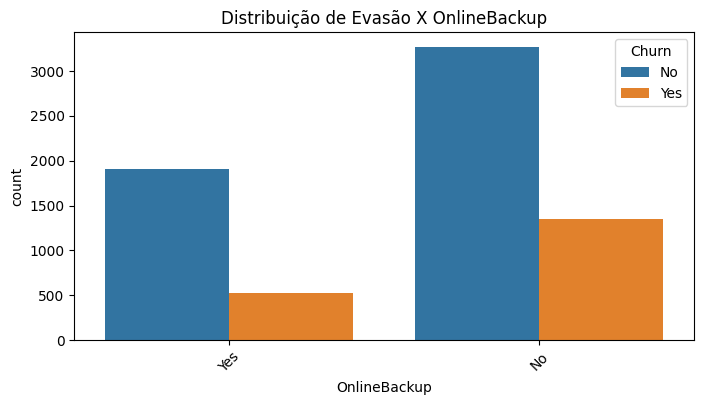

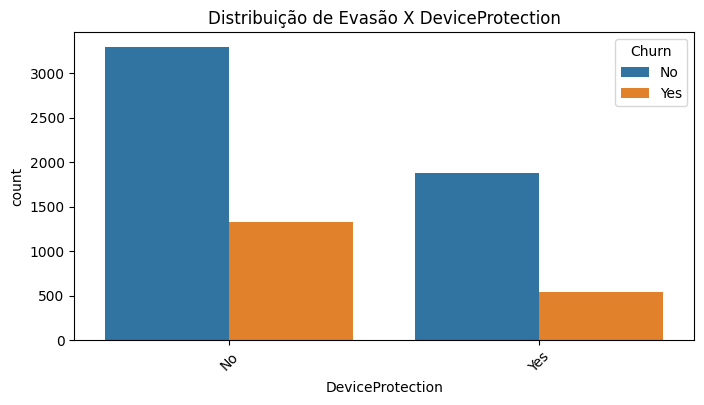

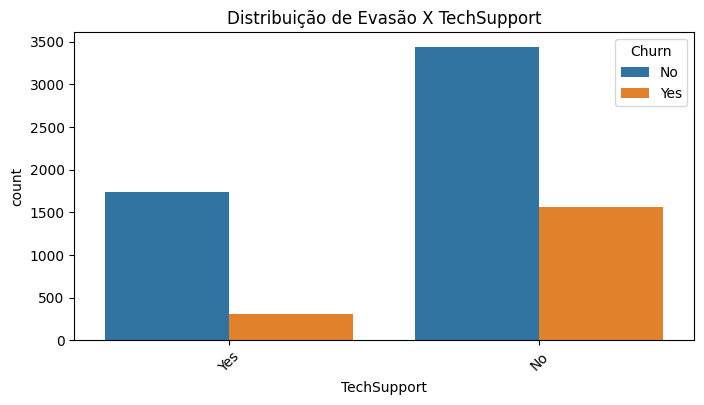

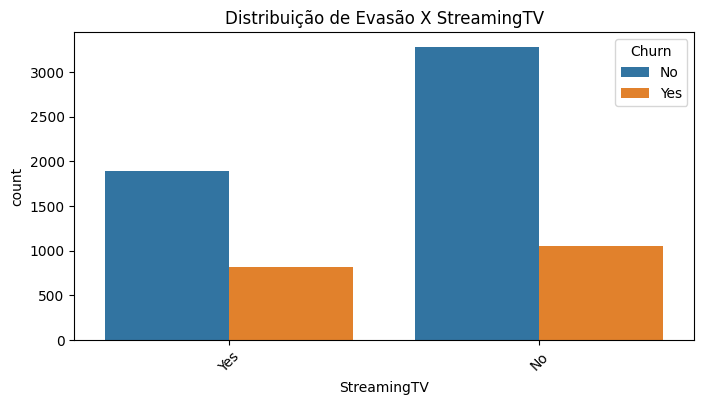

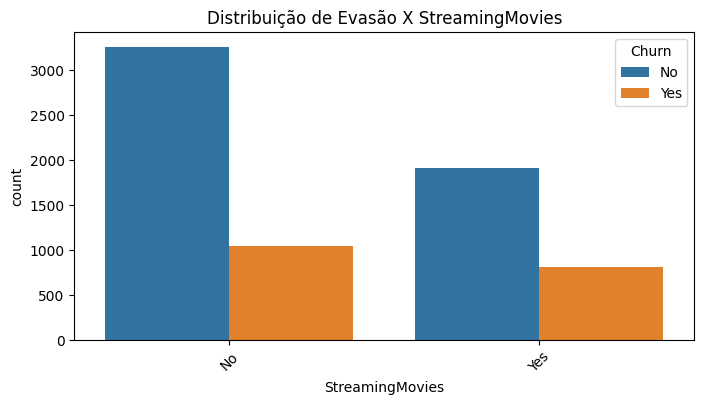

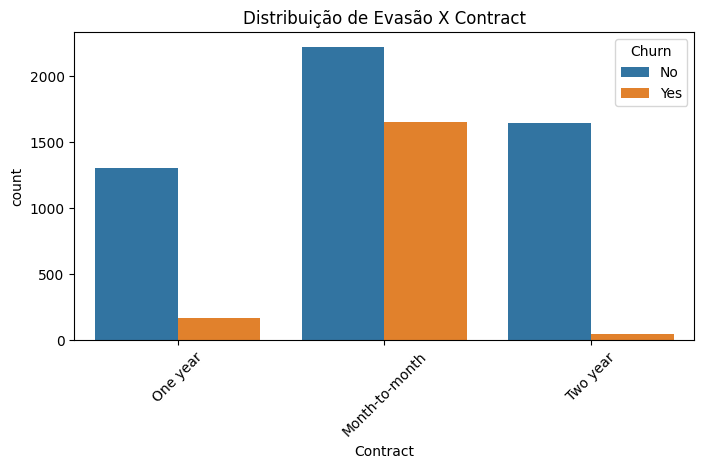

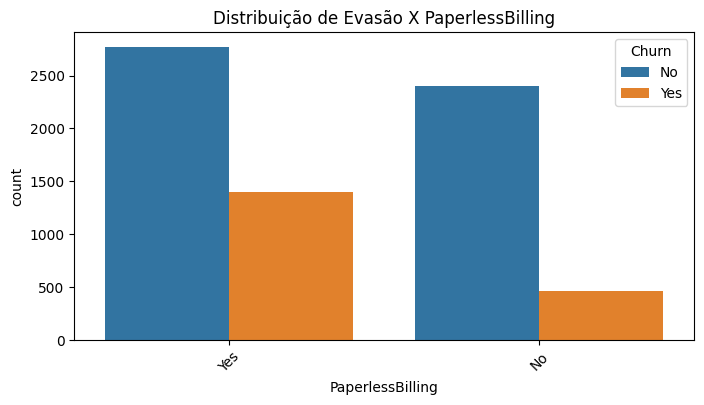

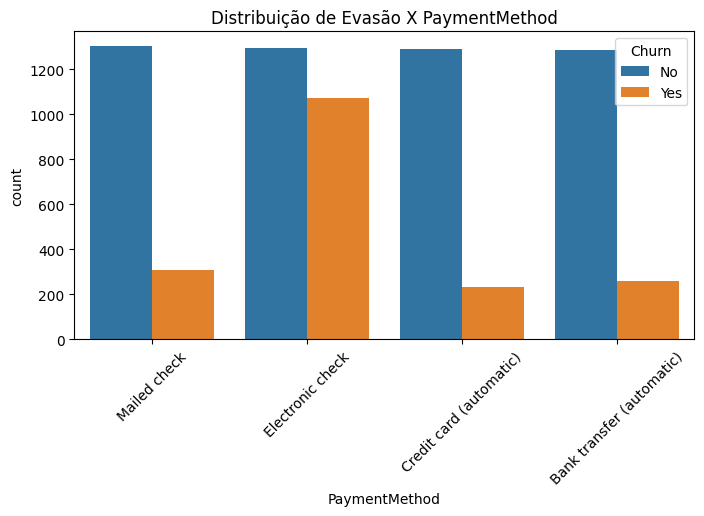

In [179]:
# Laço de repetição para criar os gráficos de evasão dentro de cada categoria
for column in colunas_categoricas:
  plt.figure(figsize = (8, 4))
  sns.countplot(data = dados,
                x = column, hue = 'Churn')
  plt.title(f'Distribuição de Evasão X {column}')
  plt.xticks(rotation = 45)
  plt.show()

In [180]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Cópia
df_rank = dados.copy()

# Converte "Churn" para binário
df_rank['Churn'] = df_rank['Churn'].map({'Yes' : 1, 'No' : 0})

# Separa variáveis categóricas
categorical_cols = df_rank.select_dtypes(include = ['object']).columns

# Aplicar Label Enconding
le = LabelEncoder()
for col in categorical_cols:
  df_rank[col] = le.fit_transform(df_rank[col])

# Separar x e y
x_cat = df_rank[categorical_cols]
y = df_rank['Churn']

# Aplicar teste qui quadrado
chi_scores, p_values = chi2(x_cat, y)

# Criar DataFrane com ranking
chi_df = pd.DataFrame({
    'variavel' : categorical_cols,
    'chi2_Score' : chi_scores,
    'p_value' : p_values
})

# Ordenar por importância
chi_df = chi_df.sort_values(by = 'chi2_Score', ascending = False)

chi_df

,variavel,chi2_Score,p_value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [181]:
variaveis_significantes = chi_df[chi_df['p_value'] < 0.05]
print('\n 🚧 Variáveis significativas (p < 0.05):')
display(variaveis_significantes)


 🚧 Variáveis significativas (p < 0.05):


,variavel,chi2_Score,p_value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [182]:
# Retirando as colunas "Gender" e "PhoneService", pois não devem entrar na correlação
dados = dados.drop(columns = ['Gender', 'PhoneService'])

In [183]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   Tenure            7043 non-null   int64  
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaperlessBilling  7043 non-null   object 
 15  PaymentMethod     7043 non-null   object 
 16  ChargesMonthly    7043 non-null   float64


## Etapa 4: ⛔ Split

Passo 1 - 🇽 ❯❯❯❯ 🇾Separação de X e Y

In [184]:
X = dados.drop('Churn', axis = 1)
y = dados['Churn']

Passo 2 - 🗿 Split

In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

Passo 3 - 1️⃣ 🌶 </> - One-Hot Enconding

In [186]:
# Aplicando One hot enconding no treino
X_train = pd.get_dummies(X_train, drop_first = True)

# Aplicando no teste
X_test = pd.get_dummies(X_test, drop_first = True)

# Garantindo que treino e teste possuam as mesmas colunas
X_train, X_test = X_train.align(X_test, join = 'left',
                                axis = 1, fill_value = 0)

In [187]:
X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


Passo 4 - ⚖️ Verificação do desbalanceamento

In [188]:
y_train.value_counts(normalize = True) * 100

,proportion
Churn,
No,73.464679
Yes,26.535321


## 🏋 Treinamentos e Testes

Modelo - 📦 🚚 ✈️ - Regressão Logística

In [189]:
# importando as bibliotecas
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print('Modelo de Regressão Logística Normal')
print(classification_report(y_test, y_pred_log_normal))

Modelo de Regressão Logística Normal
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



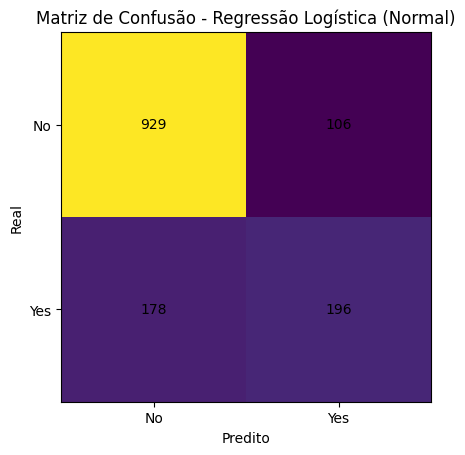

In [190]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title('Matriz de Confusão - Regressão Logística (Normal)')
plt.xlabel('Predito')
plt.ylabel('Real')

# Colocando números dentro da Matriz
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    plt.text(j, i, cm[i, j],
             ha = 'center', va = 'center')

plt.xticks([0, 1], ['No', 'Yes'])
plt.yticks([0, 1], ['No', 'Yes'])

plt.show()

In [191]:
# importando as bibliotecas
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model_bal = LogisticRegression(max_iter = 1000,
                               class_weight = 'balanced')
log_model_bal.fit(X_train, y_train)

y_pred_log_bal = log_model_bal.predict(X_test)

print('Modelo de Regressão Logística Balanceada')
print(classification_report(y_test, y_pred_log_bal))

Modelo de Regressão Logística Balanceada
              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



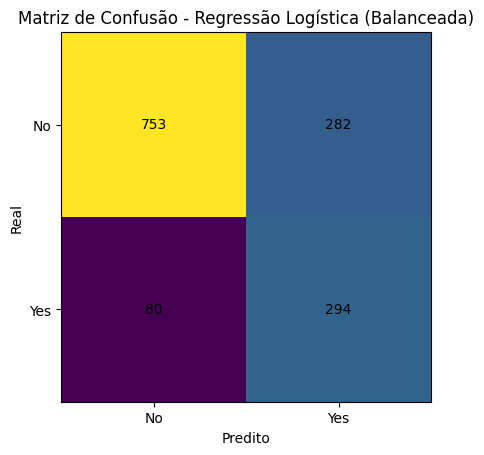

In [192]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_log_bal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title('Matriz de Confusão - Regressão Logística (Balanceada)')
plt.xlabel('Predito')
plt.ylabel('Real')

# Colocando números dentro da Matriz
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    plt.text(j, i, cm[i, j],
             ha = 'center', va = 'center')

plt.xticks([0, 1], ['No', 'Yes'])
plt.yticks([0, 1], ['No', 'Yes'])

plt.show()

Modelo - 🌲🌳🌿 - Random Forest

In [193]:
# importação da biblioteca
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print('Modelo Random Forest')
print(classification_report(y_test, y_pred_rf))

Modelo Random Forest
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



Modelo - ☃️ 👥 - Dummy

In [194]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier()
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print('Modelo Dummy')
print(classification_report(y_test, y_pred_dummy))

Modelo Dummy
              precision    recall  f1-score   support

          No       0.73      1.00      0.85      1035
         Yes       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Modelo - ❗❓ Árvore de Decisão

In [195]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

arvore = DecisionTreeClassifier(max_depth = 4, random_state = 42)
arvore.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [196]:
y_pred_arvore = arvore.predict(X_test)

print('Modelo Árvore de Decisão')
print(classification_report(y_test, y_pred_arvore))

Modelo Árvore de Decisão
              precision    recall  f1-score   support

          No       0.84      0.88      0.86      1035
         Yes       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [197]:
nome_colunas = X_train.columns.tolist()

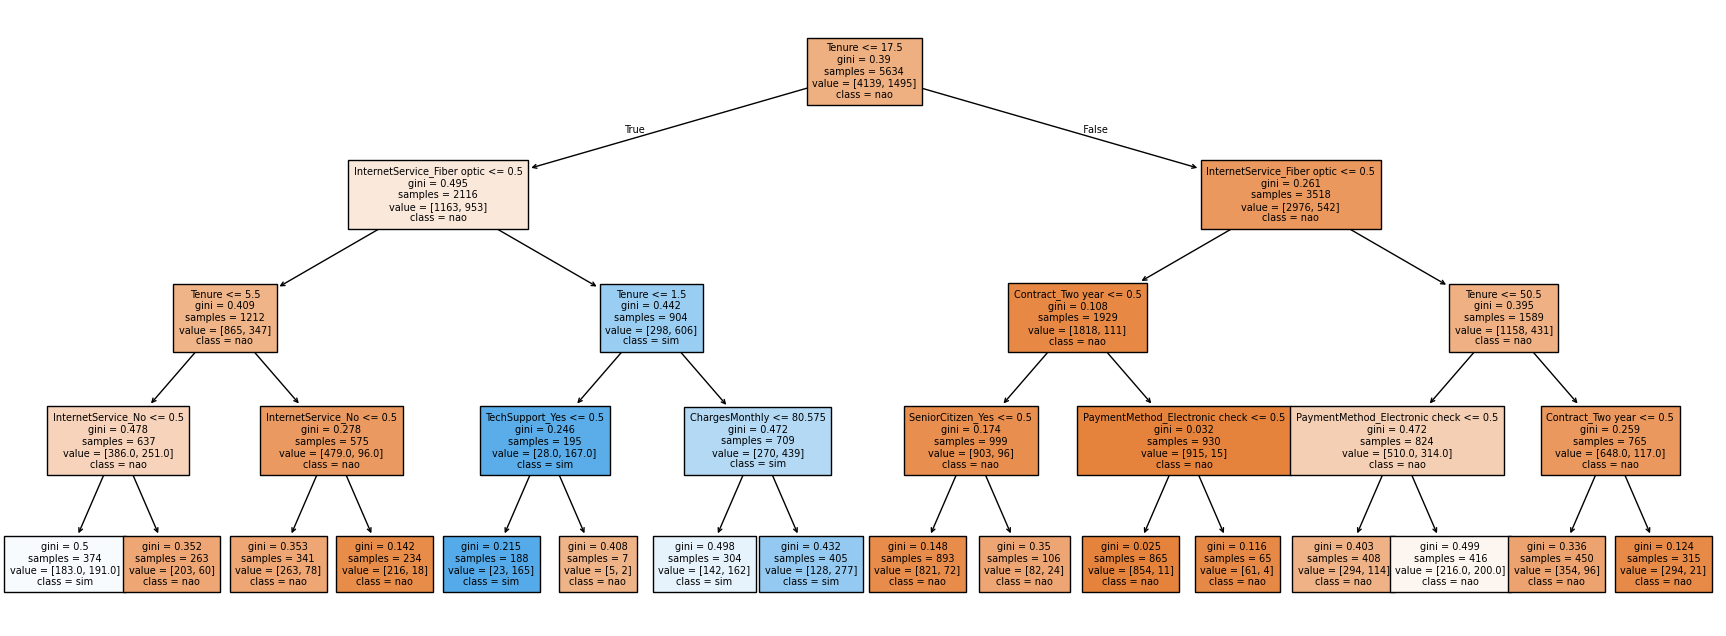

In [198]:
plt.figure(figsize = (22, 8))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 7, feature_names = nome_colunas);

Modelo - ☑️🔵✔️ - KNN

In [199]:
from sklearn.preprocessing import MinMaxScaler
normalizacao = MinMaxScaler()
X_train_normalizado = normalizacao.fit_transform(X_train)

In [200]:
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.833333,0.754360,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,0.166667,0.009467,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.027778,0.618336,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.458333,0.561535,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.194444,0.673642,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0.305556,0.023418,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5630,0.583333,0.755356,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
5631,0.277778,0.666168,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5632,0.333333,0.062780,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [201]:
# Agora com dados normalizados usaremos o modelo KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [202]:
knn.fit(X_train_normalizado, y_train)

KNeighborsClassifier()

In [203]:
X_test_normalizado = normalizacao.transform(X_test)

y_pred_knn = knn.predict(X_test_normalizado)

print('Modelo KNN')
print(classification_report(y_test, y_pred_knn))

Modelo KNN
              precision    recall  f1-score   support

          No       0.82      0.86      0.84      1035
         Yes       0.55      0.48      0.52       374

    accuracy                           0.76      1409
   macro avg       0.69      0.67      0.68      1409
weighted avg       0.75      0.76      0.75      1409



Modelo - -ˋˏ✄┈┈┈┈ - SVM

In [204]:
# importação das bibliotecas
from sklearn.svm import SVC
from sklearn.metrics import classification_report

X = dados.drop('Churn', axis = 1)
y = dados['Churn'].map({'Yes': 1, 'No': 0})

# Criando e treinando o modelo SVM
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print('Modelo SVM')
print(classification_report(y_test, y_pred_svm))

Modelo SVM
              precision    recall  f1-score   support

          No       0.81      0.94      0.87      1035
         Yes       0.70      0.39      0.50       374

    accuracy                           0.79      1409
   macro avg       0.75      0.66      0.69      1409
weighted avg       0.78      0.79      0.77      1409



In [205]:
# importação das bibliotecas
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Criando e treinando o modelo LinearSVC
svm_modelo = LinearSVC(random_state = 42,
                      dual = False, max_iter = 10000)
svm_modelo.fit(X_train, y_train)

y_pred_svm = svm_modelo.predict(X_test)

print('Modelo Linear SVM')
print(classification_report(y_test, y_pred_svm))

Modelo Linear SVM
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [206]:
# importação das bibliotecas
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Criando e treinando o modelo LinearSVC
svm_modelo = LinearSVC(random_state = 42,
                      dual = False, max_iter = 10000)
svm_modelo.fit(X_train, y_train)

y_pred_svm = svm_modelo.predict(X_test)

print('Modelo Linear SVM')
print(classification_report(y_test, y_pred_svm))

Modelo Linear SVM
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Acurácia dos modelos

In [207]:
print(f'Acurácia do Modelo ------- Regressão Logística (Normal): {round(log_model.score(X_test, y_test), 4)}')
print(f'Acurácia do Modelo --- Regressão Logística (Balanceada): {round(log_model_bal.score(X_test, y_test), 4)}')
print(f'Acurácia do Modelo -----------------------Random Forest: {round(rf_model.score(X_test, y_test), 4)}')
print(f'Acurácia do Modelo ------------------------------ Dummy: {round(dummy.score(X_test, y_test), 4)}')
print(f'Acurácia do Modelo ------------------ Árvore de Decisão: {round(arvore.score(X_test, y_test), 4)}')
print(f'Acurácia do Modelo  ------------------------------- KNN: {round(knn.score(X_test_normalizado, y_test), 4)}')
print(f'Acurácia do Modelo -------------------------------- SVM: {round(svm_model.score(X_test, y_test), 4)}')
print(f'Acurácia do Modelo ------------------------- Linear SVM: {round(svm_modelo.score(X_test, y_test), 4)}')

Acurácia do Modelo ------- Regressão Logística (Normal): 0.7984
Acurácia do Modelo --- Regressão Logística (Balanceada): 0.7431
Acurácia do Modelo -----------------------Random Forest: 0.7842
Acurácia do Modelo ------------------------------ Dummy: 0.7346
Acurácia do Modelo ------------------ Árvore de Decisão: 0.7878
Acurácia do Modelo  ------------------------------- KNN: 0.7594
Acurácia do Modelo -------------------------------- SVM: 0.7935
Acurácia do Modelo ------------------------- Linear SVM: 0.7977


Salvando os modelos:

In [208]:
# modelo de melhor acurácia
import pickle

try:
    with open('model_Regressao_Logistica_sem_balancear.pkl', 'wb') as file:
        pickle.dump(log_model, file)
    print('Modelo salvo com sucesso!!!')
except Exception as e:
    print ('Ocorreu um erro ao salvar o modelo: ', str(e))

Modelo salvo com sucesso!!!


In [209]:
import pickle

file_path = '/content/model_Regressao_Logistica_sem_balancear.pkl'

try:
    with open(file_path, 'rb') as file:
        model = pickle.load(file)
    print("Modelo carregado com sucesso!")
except Exception as e:
    print("Ocorreu um erro ao carregar o modelo:", str(e))

Modelo carregado com sucesso!


# Relatório de Análise de Churn — TelecomX

## 1. Introdução

A evasão de clientes (**Churn**) é um dos principais desafios enfrentados por empresas de telecomunicações. Quando um cliente decide cancelar um serviço, a empresa perde receita recorrente e precisa investir recursos adicionais em aquisição de novos clientes.

Neste contexto, a análise de dados e técnicas de **Machine Learning** podem ser utilizadas para identificar padrões de comportamento associados ao cancelamento de serviços.

O objetivo deste projeto é:

- Identificar **fatores que influenciam o churn**
- Construir **modelos preditivos capazes de identificar clientes com alto risco de evasão**
- Gerar **insights estratégicos para redução da perda de clientes**

A análise foi realizada utilizando **Python, Pandas, Matplotlib, Seaborn e Scikit-Learn**.

---

# 2. Importação, Limpeza e Tratamento de Dados

Antes da análise e modelagem, foi necessário realizar um processo de **preparação dos dados**, garantindo qualidade e consistência.

## 2.1 Importação dos Dados

O dataset foi carregado utilizando a biblioteca **Pandas**, permitindo manipulação eficiente das informações.

```python
import pandas as pd

df = pd.read_csv("dados_tratados.csv")
```

---

## 2.2 Inspeção Inicial

Foram analisados:

- estrutura do dataset
- tipos de variáveis
- presença de valores nulos
- consistência dos dados

Principais funções utilizadas:

```
df.head()
df.info()
df.describe()
```

---

## 2.3 Tratamento de Dados

As principais etapas realizadas foram:

- Remoção ou tratamento de **valores ausentes**
- Conversão de **variáveis categóricas**
- Padronização de **tipos de dados**
- Codificação de variáveis categóricas utilizando **One-Hot Encoding**
- Separação entre **variáveis preditoras (X)** e **variável alvo (Churn)**

Esse processo garante que os dados estejam preparados para a aplicação de **algoritmos de Machine Learning**.

---

# 3. Análise Exploratória de Dados (EDA)

A **Análise Exploratória de Dados** foi realizada com o objetivo de identificar padrões e relações entre as variáveis e o churn.

---

# 3.1 Distribuição de Churn

📊 **Gráfico: Distribuição de clientes que cancelaram vs permaneceram**

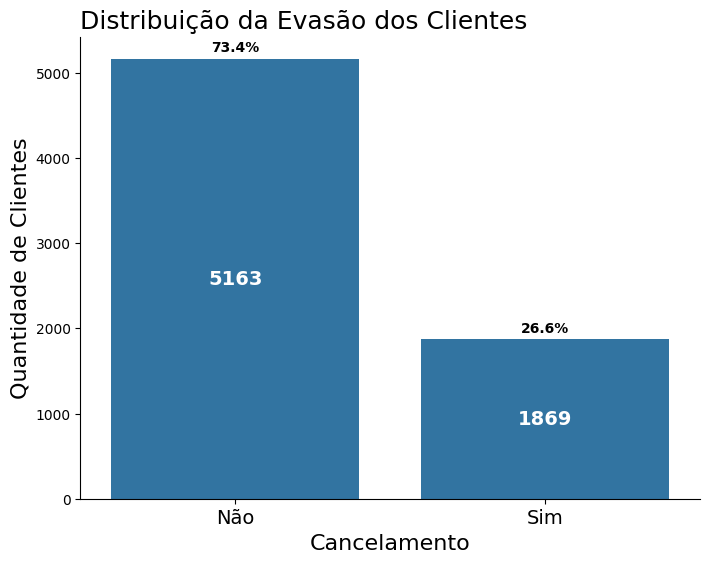

Observações:

- A maioria dos clientes permanece na empresa
- Existe uma parcela significativa de churn que justifica análise preditiva

---

# 3.2 Churn por Tipo de Contrato

📊 **Gráfico: Churn por tipo de contrato**

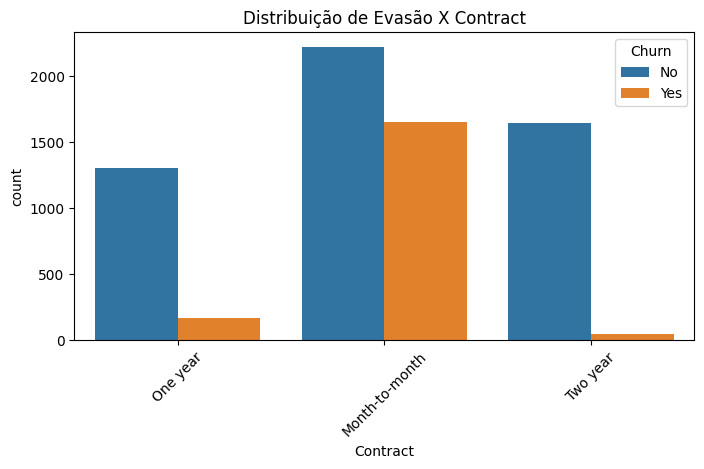

Insights:

- Clientes com **contratos mensais** apresentam maior taxa de evasão
- Contratos de longo prazo apresentam maior retenção

---

# 3.3 Churn por Tempo de Permanência (Tenure)

Insights:

- Clientes com **baixo tempo de permanência** possuem maior probabilidade de churn
- Clientes antigos tendem a ser mais fiéis

---

# 3.4 Distribuição de Gastos Mensais

Insights:

- Clientes com **mensalidades mais altas** apresentam maior tendência de cancelamento

---

# 3.5 Matriz de Correlação

📊 **Heatmap de correlação**

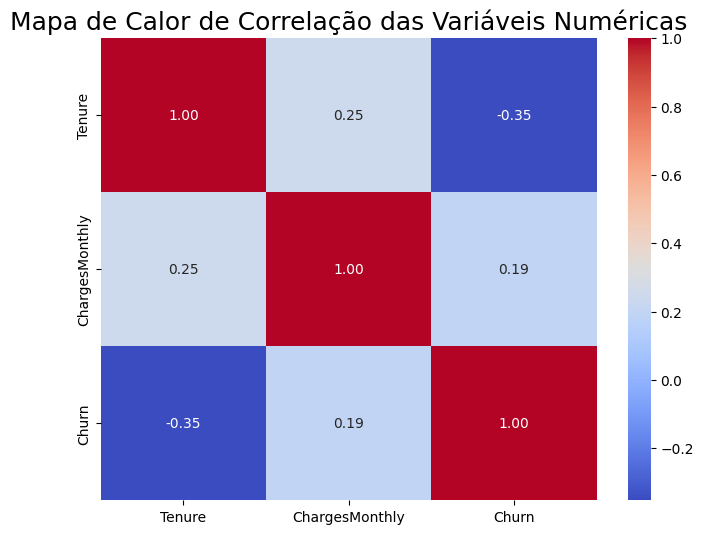

A matriz permite identificar **relações entre variáveis numéricas e churn**.

---

# 4. Modelagem Preditiva

Após o processo de limpeza e análise exploratória, foram construídos **modelos de Machine Learning para previsão de churn**.

## 4.1 Separação dos Dados

Os dados foram divididos em:

- **Treinamento (80%)**
- **Teste (20%)**

```
train_test_split()
```

---

# 5. Modelos Utilizados

Foram avaliados diferentes algoritmos de classificação:

## 5.1 Logistic Regression

Modelo estatístico amplamente utilizado para problemas de **classificação binária**.

Vantagens:

- Interpretável
- Rápido
- Bom baseline

---

## 5.2 Random Forest

Algoritmo baseado em **ensemble de árvores de decisão**.

Vantagens:

- Alta capacidade de generalização
- Lida bem com relações não lineares
- Robustez contra overfitting

---

# 6. Avaliação dos Modelos

Os modelos foram avaliados utilizando métricas clássicas de classificação.

## Métricas utilizadas

- **Accuracy**
- **Precision**
- **Recall**
- **F1-Score**

---

# 6.1 Tabela Comparativa de Métricas

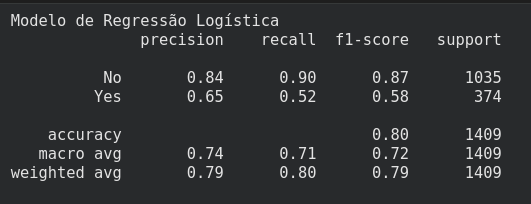 &nbsp;&nbsp;

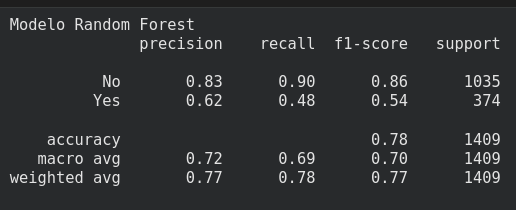

Observações:

- O **Random Forest apresentou melhor desempenho geral**
- O modelo possui melhor equilíbrio entre **precision e recall**

---

# 6.2 Matriz de Confusão

📊 Matriz de confusão do modelo

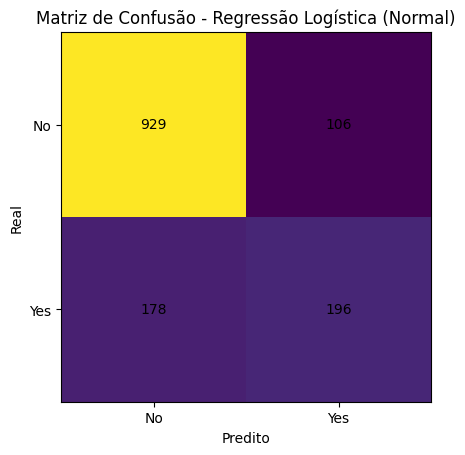

Essa visualização mostra:

- Verdadeiros positivos
- Verdadeiros negativos
- Falsos positivos
- Falsos negativos

---

# 7. Importância das Variáveis

A análise de **feature importance** permitiu identificar quais variáveis possuem maior influência na previsão de churn.

## Principais variáveis identificadas

1. **Tenure (tempo de permanência)**
2. **Tipo de contrato**
3. **Monthly Charges**
4. **Total Charges**
5. **Forma de pagamento**
6. **Serviços adicionais**

---

# 8. Interpretação dos Resultados

A análise dos modelos e da importância das variáveis indica que o churn está fortemente relacionado a fatores comportamentais e financeiros.

Principais padrões observados:

### Clientes novos

Clientes com **baixo tempo de permanência** possuem maior probabilidade de cancelamento.

### Contratos mensais

Clientes com **contratos de curto prazo** apresentam maior churn.

### Mensalidades elevadas

Planos com custos elevados podem aumentar a probabilidade de evasão.

### Baixa adoção de serviços adicionais

Clientes com poucos serviços ativos tendem a ter menor fidelização.

---

# 9. Conclusões e Insights

A análise demonstrou que é possível **identificar clientes com alto risco de churn utilizando Machine Learning**.

Os principais fatores associados ao cancelamento são:

- tipo de contrato
- tempo de permanência
- valor da mensalidade
- número de serviços contratados

Esses fatores podem ser utilizados para construir **estratégias de retenção mais eficientes**.

---

# 10. Recomendações Estratégicas

Com base nos resultados obtidos, recomenda-se:

### 1. Incentivar contratos de longo prazo

Oferecer benefícios para clientes que migrem para contratos **anuais ou bianuais**.

---

### 2. Monitoramento de novos clientes

Clientes com **menos de 6 meses de permanência** devem receber atenção especial.

---

### 3. Estratégias de fidelização

Oferecer:

- pacotes combinados
- benefícios exclusivos
- descontos progressivos

---

### 4. Uso de modelos preditivos

Implementar um sistema que identifique **clientes com alto risco de churn em tempo real**, permitindo ações preventivas.

---

# 11. Conclusão Estratégica

A utilização de **Data Science e Machine Learning** permite transformar dados operacionais em **informação estratégica**.

Com base nesta análise, a empresa pode:

- prever churn antes que ele aconteça
- direcionar campanhas de retenção
- melhorar a experiência do cliente
- reduzir perdas financeiras

Dessa forma, a aplicação de **modelos preditivos de churn** torna-se uma ferramenta essencial para a gestão estratégica em empresas de telecomunicações.